##  Market Basket Analysis Project

## Project Overview
This project focuses on analyzing retail transaction data to gain insights into customer behavior, top-selling products, sales trends, and country-wise performance. The dataset contains transactional details such as Bill Number, Item Name, Quantity, Date, Price, Customer ID, and Country.

## Library Imports

```python
import matplotlib.pyplot as plt  # For creating visualizations and plots
import pandas as pd              # For data loading, cleaning, and manipulation
import numpy as np               # For numerical operations and array handling


In [4]:
import matplotlib.pyplot as plt 

import pandas as pd
import numpy as np 


##  Loading the Dataset
Loading the dataset and displaying the first 10 rows to get an initial overview of the data.


In [9]:
df = pd.read_csv(r'C:/Users/harsh/OneDrive/Desktop/dataanalysis/Assignment-1_Data.csv', delimiter=';')

df.head(10)

C:\Users\harsh\AppData\Local\Temp\ipykernel_11628\987109505.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'C:/Users/harsh/OneDrive/Desktop/dataanalysis/Assignment-1_Data.csv', delimiter=';')


,BillNo,Itemname,Quantity,Date,Price,CustomerID,Country
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,01.12.2010 08:26,"2,55",17850.0,United Kingdom
1,536365,WHITE METAL LANTERN,6,01.12.2010 08:26,"3,39",17850.0,United Kingdom
2,536365,CREAM CUPID HEARTS COAT HANGER,8,01.12.2010 08:26,"2,75",17850.0,United Kingdom
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,01.12.2010 08:26,"3,39",17850.0,United Kingdom
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,01.12.2010 08:26,"3,39",17850.0,United Kingdom
5,536365,SET 7 BABUSHKA NESTING BOXES,2,01.12.2010 08:26,"7,65",17850.0,United Kingdom
6,536365,GLASS STAR FROSTED T-LIGHT HOLDER,6,01.12.2010 08:26,"4,25",17850.0,United Kingdom
7,536366,HAND WARMER UNION JACK,6,01.12.2010 08:28,"1,85",17850.0,United Kingdom
8,536366,HAND WARMER RED POLKA DOT,6,01.12.2010 08:28,"1,85",17850.0,United Kingdom
9,536367,ASSORTED COLOUR BIRD ORNAMENT,32,01.12.2010 08:34,"1,69",13047.0,United Kingdom


## Checking the Dataset Dimensions

In [11]:
df.shape

(522064, 7)

##  Handling Missing Values in the Dataset

- Identified missing values in the dataset.
- Replaced missing `Itemname` and `Quantity` with `'Unknown'`.
- Filled missing `CustomerID` values with the most frequent (mode) value.
- Ensured the dataset is complete by verifying there are no remaining null values.


In [16]:
missing_summary=df.isnull().sum()
df['Itemname']=df['Itemname'].fillna('Unknown')
df['Quantity']=df['Quantity'].fillna('Unknown')
# Fill NaN values in 'Itemname' with the most frequent value
df['CustomerID'] = df['CustomerID'].fillna(df['CustomerID'].mode()[0])

print(df.isnull().sum())

BillNo        0
Itemname      0
Quantity      0
Date          0
Price         0
CustomerID    0
Country       0
dtype: int64


##  Date Conversion and Feature Extraction

- Converted the `Date` column to proper datetime format using `pd.to_datetime()`, handling invalid formats with `errors='coerce'`.
- Extracted the year and month from the `Date` column and stored them in new columns: `year_added` and `month_added` for time-based analysis.


In [19]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['year_added'] = df['Date'].dt.year
df['month_added'] = df['Date'].dt.month


##  Data Cleaning and Feature Engineering

- Removed duplicate rows to ensure data accuracy using `drop_duplicates()`.
- Stripped leading/trailing spaces from `Itemname` for consistency.
- Created a new binary column `InUK` to indicate whether the transaction was made in the United Kingdom (`1`) or not (`0`).


In [25]:
df.drop_duplicates(inplace=True)
df['Itemname'] = df['Itemname'].str.strip()
df['InUK']=df['Country'].apply(lambda x:1 if x=='United Kingdom' else 0)

df.head()



,BillNo,Itemname,Quantity,Date,Price,CustomerID,Country,year_added,month_added,InUK
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-01-12 08:26:00,"2,55",17850.0,United Kingdom,2010.0,1.0,1
1,536365,WHITE METAL LANTERN,6,2010-01-12 08:26:00,"3,39",17850.0,United Kingdom,2010.0,1.0,1
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2010-01-12 08:26:00,"2,75",17850.0,United Kingdom,2010.0,1.0,1
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-01-12 08:26:00,"3,39",17850.0,United Kingdom,2010.0,1.0,1
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,2010-01-12 08:26:00,"3,39",17850.0,United Kingdom,2010.0,1.0,1


##  Descriptive Statistics Summary

- Displayed summary statistics for selected columns: `Itemname`, `Quantity`, `Country`, and `year_added`.
- Helps understand data distribution, including count, unique values, top occurrences, and frequency for categorical columns, and basic stats for numerical ones.


In [ ]:
print(df[['Itemname','Quantity','Country','year_added']].describe())

            Quantity     year_added
count  516779.000000  222221.000000
mean       10.162450    2010.884556
std       161.916374       0.319557
min     -9600.000000    2010.000000
25%         1.000000    2011.000000
50%         3.000000    2011.000000
75%        10.000000    2011.000000
max     80995.000000    2011.000000
Top 5 Countries:
 Country
United Kingdom    482403
Germany             9027
France              8393
Spain               2480
Netherlands         2363
Name: count, dtype: int64
Top 5 customers:
 CustomerID
17841.0    141640
14096.0      5111
12748.0      4413
14606.0      2677
15311.0      2366
Name: count, dtype: int64


##  Top Countries and Customers

- Identified the top 5 countries with the highest number of transactions using `value_counts()` on the `Country` column.
- Retrieved the top 5 most frequent customers based on their `CustomerID`.
- This helps highlight the most active regions and customer segments in the dataset.


In [27]:
print("Top 5 Countries:\n",df['Country'].value_counts().head())
print("Top 5 customers:\n",df['CustomerID'].value_counts().head())

Top 5 Countries:
 Country
United Kingdom    482403
Germany             9027
France              8393
Spain               2480
Netherlands         2363
Name: count, dtype: int64
Top 5 customers:
 CustomerID
17841.0    141640
14096.0      5111
12748.0      4413
14606.0      2677
15311.0      2366
Name: count, dtype: int64


## Top 10 Most Sold Items

- Grouped data by `Itemname` and summed up the `Quantity` sold for each item.
- Sorted the items in descending order to identify the top 10 best-selling products.
- Visualized the results using a bar chart to show which items were sold the most.
- This helps in understanding product popularity and demand trends.


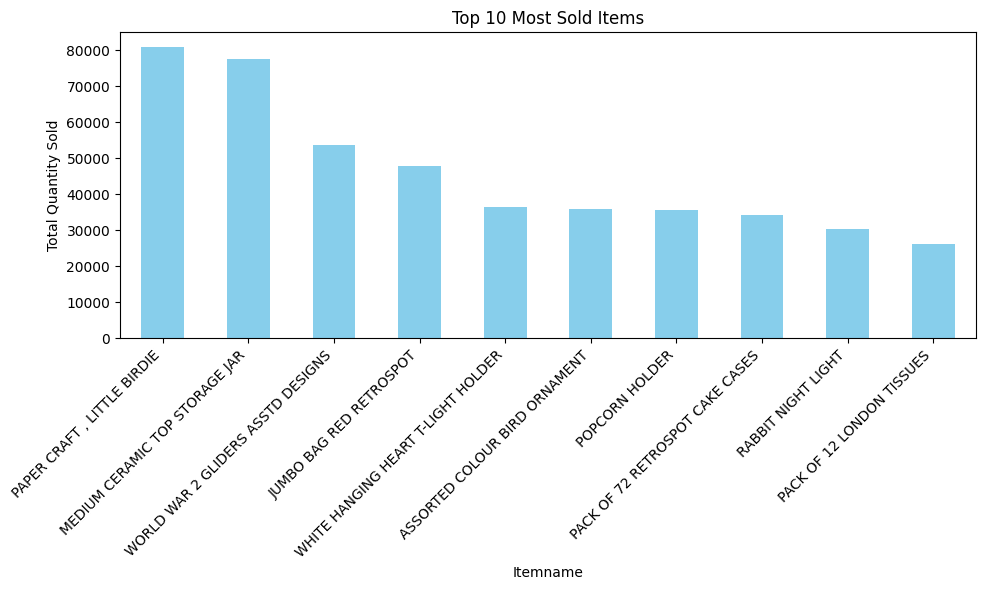

In [28]:
top_items = df.groupby('Itemname')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_items.plot(kind='bar', color='skyblue')
plt.title('Top 10 Most Sold Items')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##  Price Conversion and Sales Calculation

- Converted the `Price` column from string to float by replacing commas with dots to ensure proper numerical format.
- Calculated a new `Sales` column by multiplying `Quantity` and `Price`, representing the total sales value per transaction.


In [29]:
df['Price'] = df['Price'].str.replace(',', '.').astype(float)
df['Sales'] = df['Quantity'] * df['Price']

##  Top 10 Countries by Total Sales

- Grouped the data by `Country` and summed the `Sales` for each.
- Sorted the countries to identify the top 10 with the highest total sales.
- Displayed the results in a bar chart to highlight the most profitable markets.


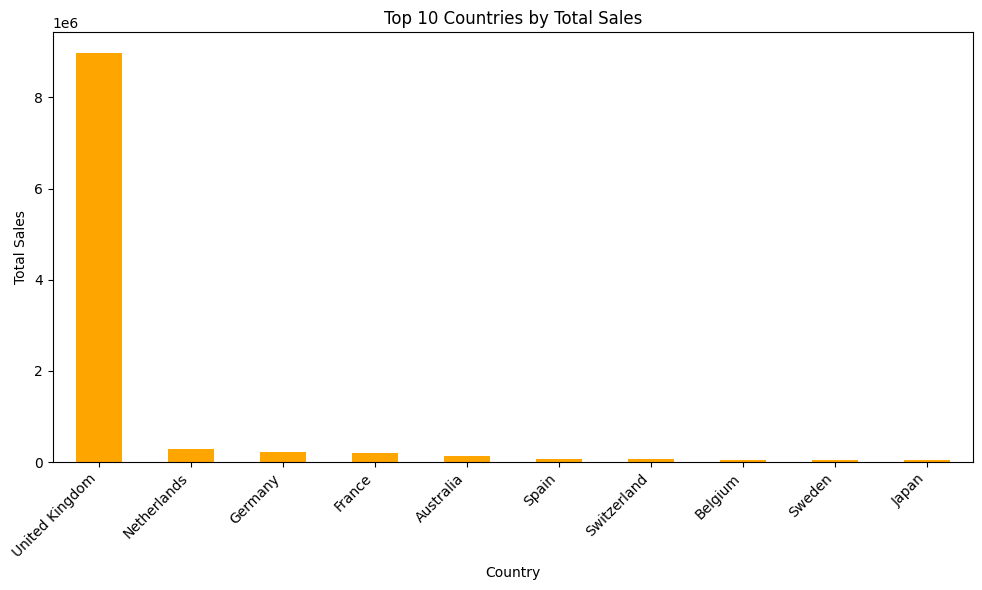

In [30]:
top_countries = df.groupby('Country')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_countries.plot(kind='bar', color='orange')
plt.title('Top 10 Countries by Total Sales')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##  Date Formatting and Extraction

- Converted the `Date` column to datetime format with `dayfirst=True` to correctly interpret dates.
- Created a new column `Day` that contains only the date part (year-month-day) for easier daily-level analysis.


In [31]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Day'] = df['Date'].dt.date


##  Daily Number of Unique Orders

- Grouped the dataset by `Day` and counted unique `BillNo` to find the number of distinct transactions per day.
- Plotted a line graph to visualize daily transaction trends over time.
- This helps in understanding the sales activity and seasonality in the dataset.


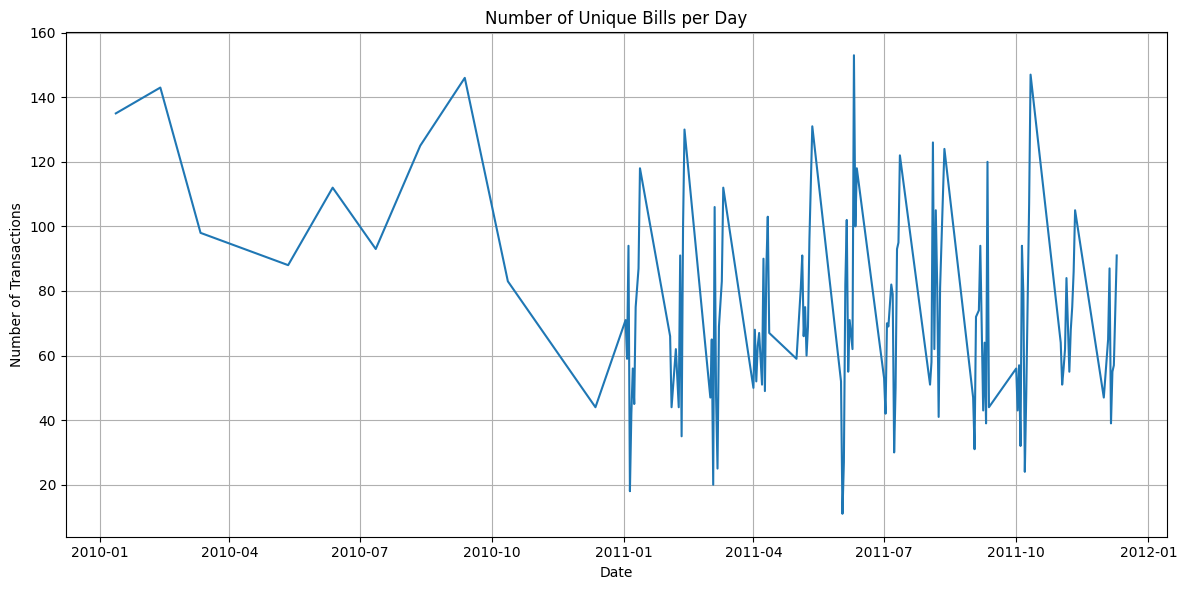

In [32]:
daily_orders = df.groupby('Day')['BillNo'].nunique()

plt.figure(figsize=(12,6))
daily_orders.plot()
plt.title('Number of Unique Bills per Day')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.tight_layout()
plt.show()
